## **A State-Space Approach to CDC Surveillance Data**

In the following project, I use a Kalman Filter to recover the true flu signal from noisy observations. I use CDC Surveillance Data on Flu Positivity in Illinois for October 2010 to March 2026.

### Import Libraries

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
from scipy.optimize import minimize
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from py_modules.coverage_analysis import empirical_coverage
from py_modules.kf_core_functions import kf_update, kf_predict
from py_modules.baseline_functions import build_baseline_matrices, neg_log_likelihood_baseline, run_baseline_filter
from py_modules.llt_functions import build_llt_matrices, neg_log_likelihood_llt, run_llt_filter
from py_modules.seasonal_functions import build_fourier_features, build_seasonal_matrices, neg_log_likelihood_seasonal, run_seasonal_filter
from py_modules.forecast_functions import forecast, forecast_seasonal

### Load and Split Data

In [67]:
flu10_15 = pd.read_csv('ICL_NREVSS_Combined_prior_to_2015_16.csv', header=1)
flu15_present = pd.read_csv('ICL_NREVSS_Clinical_Labs.csv', header=1)

cols = ['REGION TYPE', 'REGION', 'YEAR', 'WEEK', 'PERCENT POSITIVE']
flu = pd.concat([flu10_15[cols], flu15_present[cols]], ignore_index=True)
flu = flu[flu['PERCENT POSITIVE'] != 'X']
flu['PERCENT POSITIVE'] = pd.to_numeric(flu['PERCENT POSITIVE'], errors='coerce')

In [68]:
flu['DATE'] = pd.to_datetime(flu['YEAR'].astype(str) + 
              flu['WEEK'].astype(str).str.zfill(2) + '1', format='%Y%W%w')

flu['MONTH'] = flu['DATE'].dt.month
flu['MONTH_YEAR'] = flu['DATE'].dt.to_period('M')  # e.g. "2023-02"

In [69]:
# Split Data 
flu = flu[(flu['REGION']=='Illinois')]
flu = flu.sort_values(['YEAR', 'WEEK']).reset_index(drop=True)
cutoff = int(len(flu) * 0.8)
train = flu.reset_index().iloc[:cutoff, :]
test = flu.reset_index().iloc[cutoff:, :]

The test data starts in February 2023.

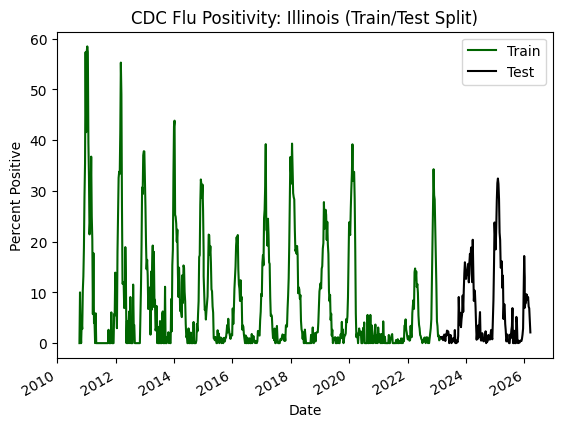

In [70]:
fig, ax = plt.subplots()

ax.plot(train['DATE'], train['PERCENT POSITIVE'], label='Train', color='darkgreen')
ax.plot(test['DATE'], test['PERCENT POSITIVE'], label='Test', color='black')
ax.set_xlabel('Date')
ax.set_ylabel('Percent Positive')
ax.set_title('CDC Flu Positivity: Illinois (Train/Test Split)')
ax.legend()
fig.autofmt_xdate()
plt.show()

As we can infer from the plot ("CDC Flu Positivity: Illinois (Train/Test Split)"), the data ranges from 0 to 58 with huge spikes, and the variance during peak flu season is completely different from the variance during off-season. Therefore, we need to use a log transformation to compresses the peaks and stretches, making the variance more uniform across the whole series so the optimizer has a better chance of find meaningful values for Q and R.

In [71]:
train['LOG_PP'] = np.log1p(train['PERCENT POSITIVE'])
test['LOG_PP'] = np.log1p(test['PERCENT POSITIVE'])

train_log = np.log1p(train['PERCENT POSITIVE'].values)

### Kalman Filter Core Functions

The following functions are used to execute the core functions of the Kalman Filter, following the procedure in Welch & Bishop (2006).

Time Update ("Predict")

1. Project the state ahead: $\hat{x}_k^- = A\hat{x}_{k-1} + Bu_{k-1}$

2. Project the error covariance ahead: $P_k^- = AP_{k-1}A^T + Q$

Measurement Update ("Correct")

1. Compute the Kalman gain: $K_k = P_k^- H^T (HP_k^- H^T + R)^{-1}$

2. Update estimate with measurement $z_k$: $\hat{x}_k = \hat{x}_k^- + K_k(z_k - H\hat{x}_k^-)$

3. Update the error covariance: $P_k = (I - K_kH)P_k^-$

### Maximum Likelihood Estimation of $Q$ and $R$ using L-BFGS-B

To find values for $Q$ and $R$, I use the L-BFGS-B procedure as outlined in detail by Byrd et. al. (1994). Zhu et. al. (1994) provide a rough outline of the algorithm:

At each iteration, a limited memory BFGS approximation to the Hessian is updated. This limited memory matrix is used to determine a quadratic model of the objective function $f$. A search direction is then computed using a two-stage approach:
1. the gradient projection method is used to identify a set of active variables; i.e., variables that will be held at their bounds.
2. Then the quadratic model is approximately minimized with respect to the free variables. The search direction is defined to be the vector leading from the current iterate to this approximate minimizer.
3. Finally a line search is performed along the search direction using the subroutine described in More and Thuente (1990).

#### Connecting the Kalman Filter and L-BFGS-B

The Kalman filter and the L-BFGS-B optimizer work together as follows. For a given pair of candidate values $(Q, R)$, the Kalman filter is run over the full time series, producing at each time step the innovation $v_k = z_k - H\hat{x}_k^-$ and its variance $S_k = HP_k^-H^T + R$. The log-likelihood of the data given those parameters is then

$$\log L(Q, R) = -\frac{1}{2}\sum_{k=1}^{N}\left[\log S_k + \frac{v_k^2}{S_k}\right]$$

up to an additive constant. This is the objective function $f$ that L-BFGS-B minimizes (in practice we minimize the negative log-likelihood). Each time L-BFGS-B proposes new values of $Q$ and $R$, the Kalman filter reruns from scratch, returns a new log-likelihood, and L-BFGS-B uses the change in the objective and its gradient to update its Hessian approximation and propose the next candidate. The bound constraints in L-BFGS-B ensure that $Q$ and $R$ remain positive throughout the search, which is required since they represent variances.

### **Model 1: Scalar Random Walk**

Here, we build a baseline single-state model that smooths the raw signal.

In [72]:
y = train['LOG_PP'].values[1:]                    # x_k
X = train['LOG_PP'].values[:-1].reshape(-1, 1)    # x_{k-1}

reg = LinearRegression(fit_intercept=False)
reg.fit(X, y)
A_est = reg.coef_[0]

A_est

np.float64(0.9345550712100781)

The estimated value of $A \approx 0.93$ indicates mild mean reversion; the signal retains about 93% of its value each week. This value of $A$ is close to a random walk (i.e., where A = 1), and is reasonable for flu positivity data where week-to-week changes are small relative to the level.

In [ ]:
result_baseline = minimize(neg_log_likelihood_baseline,
                           x0=np.log([1.0, 5.0]),
                           args=(train['LOG_PP'].values, A_est),
                           method='L-BFGS-B', 
                           bounds=[(-15, 10), (-15, 10)])

best_nll_baseline = result_baseline.fun

Q_mle_baseline, R_mle_baseline = np.exp(result_baseline.x)
print(f"Q: {Q_mle_baseline:.4f}, R: {R_mle_baseline:.4f}")
print(f"Q/R ratio: {Q_mle_baseline/R_mle_baseline:.4f}")
print(f"Converged: {result_baseline.success}")

A_base, H_base, Q_base, R_base = build_baseline_matrices(A_est, Q_mle_baseline, R_mle_baseline)

Q: 0.2061, R: 0.1224
Q/R ratio: 1.6838
Converged: True


The Q/R ratio of 1.68 means the filter splits trust roughly evenly between the process model and observations, with a slight lean toward believing real changes. In practical terms, when the filter sees a spike, it mostly believes it's real but applies meaningful smoothing rather than tracking the observation one-for-one.

In [74]:
# Run filter on log-transformed test data
test_measurements = test['PERCENT POSITIVE'].values
parameters = [A_est, Q_mle_baseline, R_mle_baseline]
test_log = np.log1p(test['PERCENT POSITIVE'].values)

# Warm up Model 1
_, _, _, xk_warm_1, Pk_warm_1, _, _, _, _ = run_baseline_filter(
    [A_est, Q_mle_baseline, R_mle_baseline], train_log)

# Run on test with warmed-up state
baseline_states_log, baseline_upper_log, baseline_lower_log, xk_base, Pk_base, xk_rts_base, Pk_rts_base, Pk_bars_base, vk_base = run_baseline_filter(
    parameters, test_log, xk_init=xk_warm_1, Pk_init=Pk_warm_1)

# Transform back to original scale for plotting
baseline_states = np.expm1(baseline_states_log)
baseline_upper = np.expm1(baseline_upper_log)
baseline_lower = np.maximum(np.expm1(baseline_lower_log), 0)
test_raw = test['PERCENT POSITIVE'].values

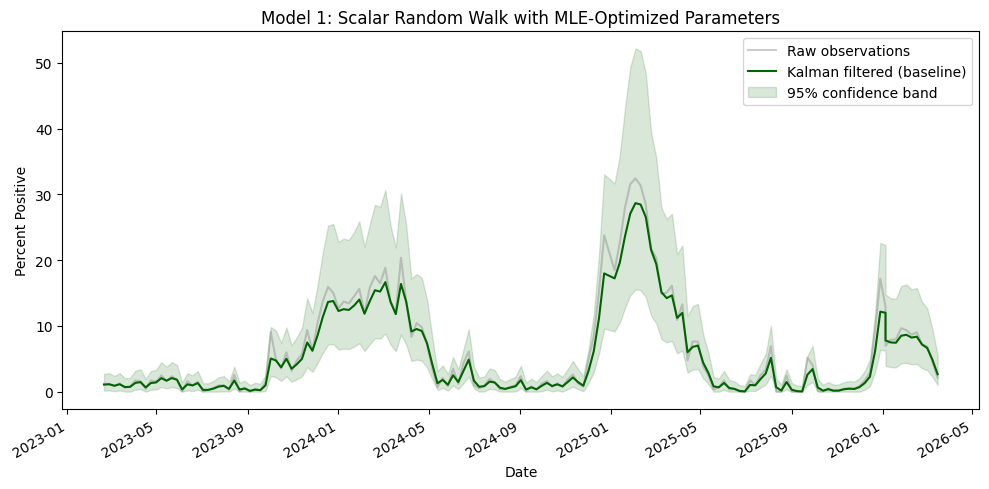

In [75]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test['DATE'], test_measurements, alpha=0.4, label='Raw observations', color='gray')
ax.plot(test['DATE'], baseline_states, label='Kalman filtered (baseline)', color='darkgreen')
ax.fill_between(test['DATE'], baseline_lower, baseline_upper, 
                alpha=0.15, color='darkgreen', label='95% confidence band')
ax.set_xlabel('Date')
ax.set_ylabel('Percent Positive')
ax.set_title('Model 1: Scalar Random Walk with MLE-Optimized Parameters')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [76]:
ca_base_params = test_raw, baseline_lower, baseline_upper
print(f'Empirical Coverage (Baseline Model): {empirical_coverage(ca_base_params)}')

ljb_base = acorr_ljungbox(vk_base, lags=52, return_df=True)
print(f'Percentage of p-values < 0.05 (Baseline Model): {len(ljb_base[ljb_base['lb_pvalue'] < 0.05]) / len(ljb_base)}')

Empirical Coverage (Baseline Model): 1.0
Percentage of p-values < 0.05 (Baseline Model): 0.0


Model 1's innovations pass the Ljung-Box test at all lags (minimum p-value ≈ 0.09 at lag 7), confirming no residual autocorrelation. However, the 100% empirical coverage against a nominal 95% band indicates the model is substantially underconfident; the bands are too wide to be informative. The model is well-specified but poorly calibrated, motivating the need for structural models (Models 2 and 3) with tighter uncertainty estimates.

### **Model 2: Local Linear Trend**

In [77]:
Q_level = [-2, 0, 2]
Q_trend = [-4, -2, 0]
R_val = [-1, 0, 1]

vectors = [Q_level, Q_trend, R_val]

best_nll_llt = np.inf
best_result_llt = None

for combo in product(Q_level, Q_trend, R_val):
    result_llt = minimize(neg_log_likelihood_llt,
                            x0=(combo[0], combo[1], combo[2]),
                            args=(train['LOG_PP'].values),
                            method='L-BFGS-B', 
                            bounds=([(-15, 10)] * 3))
    if result_llt.fun < best_nll_llt:
        best_nll_llt = result_llt.fun
        best_result_llt = result_llt

q_level_mle, q_trend_mle, r_mle_llt = np.exp(best_result_llt.x)
print(f"Q Level: {q_level_mle:.4f}, Q Trend: {q_trend_mle:.6f}, R: {r_mle_llt:.4f}")
print(f"Q_level/R: {q_level_mle/r_mle_llt:.4f}")
print(f"Q_trend/R: {q_trend_mle/r_mle_llt:.6f}")
print(f"Converged: {best_result_llt.success}")

A_llt, H_llt, Q_llt, R_llt = build_llt_matrices(q_level_mle, q_trend_mle, r_mle_llt)

Q Level: 0.1651, Q Trend: 0.000000, R: 0.1416
Q_level/R: 1.1660
Q_trend/R: 0.000002
Converged: True


The MLE drives $\hat{Q}_{trend}$ to effectively zero ($\approx 10^{-6}$), indicating that the data does not support a time-varying trend component. The optimizer has learned that allowing the trend state to wander freely does not improve the log-likelihood — the local linear trend model collapses back to a level-only model.

It tells us that CDC flu positivity in Illinois, after log transformation, does not exhibit a meaningful long-term drift. The series is better characterized as fluctuating around a slowly-moving level than as following a systematic upward or downward trajectory.

The $Q_{level}/R$ ratio dropped from $\approx 8.0$ (Model 1) to $\approx 1.17$, meaning the filter now splits trust roughly evenly between the process model and observations. Despite the trend state being effectively dead, the rebalancing of $Q_{level}$ and $R$ represents a meaningfully different filtering regime — the model smooths more aggressively than the baseline.


In [78]:
# Run filter on log-transformed test data
test_measurements = test['PERCENT POSITIVE'].values
parameters = [q_level_mle, q_trend_mle, r_mle_llt]
test_log = np.log1p(test['PERCENT POSITIVE'].values)

# Warm up Model 2
_, _, _, _, xk_warm_2, Pk_warm_2, _, _, _, _ = run_llt_filter(parameters, train_log)

# Run on test with warmed-up state
llt_states_log, llt_trends_log, llt_upper_log, llt_lower_log, xk_llt, Pk_llt, xk_rts_llt, Pk_rts_llt, Pk_bars_llt, vk_llt = run_llt_filter(
    parameters, test_log, xk_init=xk_warm_2, Pk_init=Pk_warm_2)

# Transform back to original scale for plotting
llt_states = np.expm1(llt_states_log)
llt_upper = np.expm1(llt_upper_log)
llt_lower = np.maximum(np.expm1(llt_lower_log), 0)
test_raw = test['PERCENT POSITIVE'].values

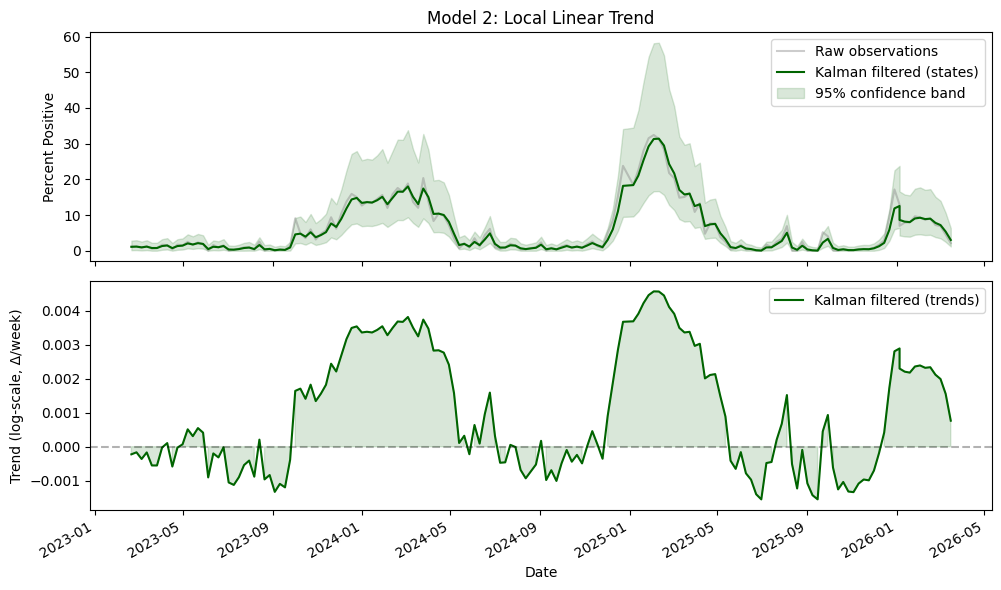

In [79]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(test['DATE'], test_measurements, alpha=0.4, label='Raw observations', color='gray')
axs[0].plot(test['DATE'], llt_states, label='Kalman filtered (states)', color='darkgreen')
axs[0].fill_between(test['DATE'], llt_lower, llt_upper, 
                alpha=0.15, color='darkgreen', label='95% confidence band')
axs[0].set_ylabel('Percent Positive')
axs[0].set_title('Model 2: Local Linear Trend')
axs[0].legend()

axs[1].plot(test['DATE'], llt_trends_log, label='Kalman filtered (trends)', color='darkgreen')
axs[1].fill_between(test['DATE'], llt_trends_log, 
                    where=(llt_trends_log>0), color='darkgreen', alpha=0.15)
axs[1].fill_between(test['DATE'], llt_trends_log, 
                    where=(llt_trends_log<0), color='darkgreen', alpha=0.15)                
axs[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Trend (log-scale, \u0394/week)')
axs[1].legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [80]:
ca_llt_params = test_raw, llt_lower, llt_upper
print(f'Empirical Coverage (LLT Model): {empirical_coverage(ca_llt_params)}')

ljb_llt = acorr_ljungbox(vk_llt, lags=52, return_df=True)
print(f'Percentage of p-values < 0.05 (LLT Model): {len(ljb_llt[ljb_llt['lb_pvalue'] < 0.05]) / len(ljb_llt)}')

Empirical Coverage (LLT Model): 0.9875776397515528
Percentage of p-values < 0.05 (LLT Model): 0.0


98.8% of test observations fall inside the 95% confidence band, marking a substantial improvement over Model 1's 100% coverage and much closer to the nominal 95% level. The filter is producing meaningfully tighter uncertainty bands.

This improvement is driven by the rebalanced $Q_{level}/R$ ratio. Model 1's ratio of $\approx 8.0$ caused the filter to track observations almost verbatim and compensate with inflated uncertainty. Model 2's ratio of $\approx 1.17$ splits trust roughly evenly between the process model and observations, producing a smoother state estimate that the filter is more willing to commit to.

Notably, this calibration improvement occurs despite the trend component being effectively dead ($\hat{Q}_{trend} \approx 10^{-6}$). The benefit comes not from the trend structure itself but from the re-optimization of the level and observation noise parameters in the presence of the additional (unused) state. This suggests that Model 1's MLE was settling in a regime that over-trusted observations, and the expanded parameterization of Model 2 allowed the optimizer to find a better-calibrated partition of process and observation noise.

The standardized innovations show no significant autocorrelation at any lag from 1 to 52 (0% of $p$-values below 0.05). As with Model 1, the temporal dependence structure is fully captured — no systematic patterns remain in the prediction errors.

### **Model 3: Seasonal Structural Model**

Any time series can be decomposed into a sum of sine and cosine waves at different frequencies (Shumway & Stoffer, 2017, §4.1). For seasonal flu data with a 52-week period, we approximate the seasonal component using $H$ harmonics:

$$s_k = \sum_{h=1}^{H} \left[ a_h \cos(2\pi k \cdot h / 52) + b_h \sin(2\pi k \cdot h / 52) \right]$$

where

$$a_h = \frac{2}{n} \sum_{k=1}^{n} x_k \cos(2\pi k \cdot h/52) \quad \text{and} \quad b_h = \frac{2}{n} \sum_{k=1}^{n} x_k \sin(2\pi k \cdot h/52)$$

At each time step:
- The level gets pushed by trend: $level_{k+1} = level_k + trend_k$
- The trend persists: $trend_{k+1} = trend_k$
- Each Fourier coefficient persists unchanged: ${\beta}_{k+1} = \beta_k$

That means $A$ is an 8×8 identity matrix with the extra entry, $A[0, 1] = 1$, because the trend is added to the level.

The observation matrix $H_k$ is time-varying. At each step $k$, $H_k$ has to pick out the level plus the seasonal effect for that specific week. It's a 1×8 row vector:

$$H_k = \begin{bmatrix} 1 & 0 & \sin(2\pi \cdot 1 \cdot w_k / 52) & \cos(2\pi \cdot 1 \cdot w_k / 52) & \sin(2\pi \cdot 2 \cdot w_k / 52) & \cos(2\pi \cdot 2 \cdot w_k / 52) & \sin(2\pi \cdot 3 \cdot w_k / 52) & \cos(2\pi \cdot 3 \cdot w_k / 52) \end{bmatrix}$$

In addition to Fourier Transformation, a fixed observation noise $R$ struggled to simultaneously capture calm periods and outbreak surges, resulting in either overconfident bands during spikes or overly wide bands during stable periods. To address this, $R$ was made time-varying using an exponential moving average anchored to the baseline: $$R_k = \alpha · v_k^2 + (1 − \alpha) · R_0$$
where $v_k$ is the innovation at time $k$, $R_0$ is the baseline observation noise, and $\alpha$ controls the adaptation rate. This formulation allows $R$ to spike during outbreaks (when innovations are large) and naturally decay back to $R_0$ during calm periods. The parameter $\alpha$ was estimated jointly with the other model parameters via maximum likelihood.

In [81]:
Q_level = [-2, 0, 2]
Q_trend = [-4, -2, 0]
Q_seasonal_pre = [-4, -2, 0]
Q_seasonal_post = [-4, -2, 0]
R_val = [-1, 0, 1]

# Precompute ONCE before the grid search
fourier = build_fourier_features(train['WEEK'].values)
covid_start = pd.Timestamp('2020-03-11')
covid_mask = train['DATE'].values >= covid_start
measurements = train['LOG_PP'].values

# Warm up JIT (first call compiles)
_ = neg_log_likelihood_seasonal(np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0]), 
                                measurements, fourier, covid_mask)

best_nll_seasonal = np.inf
best_result_seasonal = None

alpha_init = [0]  # sigmoid(0) = 0.5

for combo in product(Q_level, Q_trend, Q_seasonal_pre, Q_seasonal_post, R_val, alpha_init):
    result = minimize(neg_log_likelihood_seasonal,
                      x0=np.array(combo, dtype=np.float64),
                      args=(measurements, fourier, covid_mask),
                      bounds=[(-15, 10)] * 4 + [(-15, 2)] + [(-5, 5)]) # Prevent R from Exploding
    if result.fun < best_nll_seasonal:
        best_nll_seasonal = result.fun
        best_result_seasonal = result

q_level_s, q_trend_s, q_seasonal_pre_s, q_seasonal_post_s, r_s, alpha_raw = best_result_seasonal.x
q_level_s, q_trend_s, q_seasonal_pre_s, q_seasonal_post_s, r_s = np.exp([q_level_s, q_trend_s, q_seasonal_pre_s, q_seasonal_post_s, r_s])
alpha_s = 1.0 / (1.0 + np.exp(-alpha_raw))

print(f"Q Level: {q_level_s:.4f}, Q Trend: {q_trend_s:.6f}, Q Seasonal (Pre-Covid): {
    q_seasonal_pre_s:.6f}, Q Seasonal (Post-Covid): {q_seasonal_post_s:.6f}, R: {r_s:.4f}")
print(f"Alpha: {alpha_s:.4f}")
print(f"Q_level/R: {q_level_s/r_s:.4f}")
print(f"Q_trend/R: {q_trend_s/r_s:.6f}")
print(f"Q_seasonal_pre/R: {q_seasonal_pre_s/r_s:.6f}")
print(f"Q_seasonal_post/R: {q_seasonal_post_s/r_s:.6f}")
print(f"Converged: {best_result_seasonal.success}")

Q Level: 0.0101, Q Trend: 0.000000, Q Seasonal (Pre-Covid): 0.002068, Q Seasonal (Post-Covid): 0.004711, R: 0.1704
Alpha: 0.2515
Q_level/R: 0.0592
Q_trend/R: 0.000002
Q_seasonal_pre/R: 0.012135
Q_seasonal_post/R: 0.027642
Converged: True


The near-zero $Q_{trend}$ indicates the trend component evolves very slowly, consistent with flu activity having a stable long-run trajectory. The post-COVID seasonal variance is roughly double the pre-COVID value, confirming that seasonal patterns became less predictable after the pandemic. The adaptation rate $\alpha$ ≈ 0.25 means observation noise responds meaningfully to surprises but remains anchored to the baseline.

In [82]:
# Run filter on log-transformed test data
test_measurements_seasonal = test['PERCENT POSITIVE'].values
parameters_seasonal = [q_level_s, q_trend_s, q_seasonal_pre_s, q_seasonal_post_s, r_s, alpha_s]
test_log_seasonal = np.log1p(test['PERCENT POSITIVE'].values)
train_log = np.log1p(train['PERCENT POSITIVE'].values)

# Warm up Model 3
_, _, _, _, _, xk_warm_3, Pk_warm_3, _, _, _, _ = run_seasonal_filter(
    parameters_seasonal, train_log, train['WEEK'].values, train['DATE'].values)

# Run on test with warmed-up state
seasonal_states_log, seasonal_trends_log, seasonal_log, seasonal_upper_log, seasonal_lower_log, xk_seasonal, Pk_seasonal, vk_seasonal, _, _, _ = run_seasonal_filter(
    parameters_seasonal, test_log_seasonal, test['WEEK'].values, test['DATE'].values, 
    xk_init=xk_warm_3, Pk_init=Pk_warm_3)

seasonal_states = np.expm1(seasonal_states_log)
seasonal_upper = np.expm1(seasonal_upper_log)
seasonal_lower = np.maximum(np.expm1(seasonal_lower_log), 0)
test_raw = test['PERCENT POSITIVE'].values

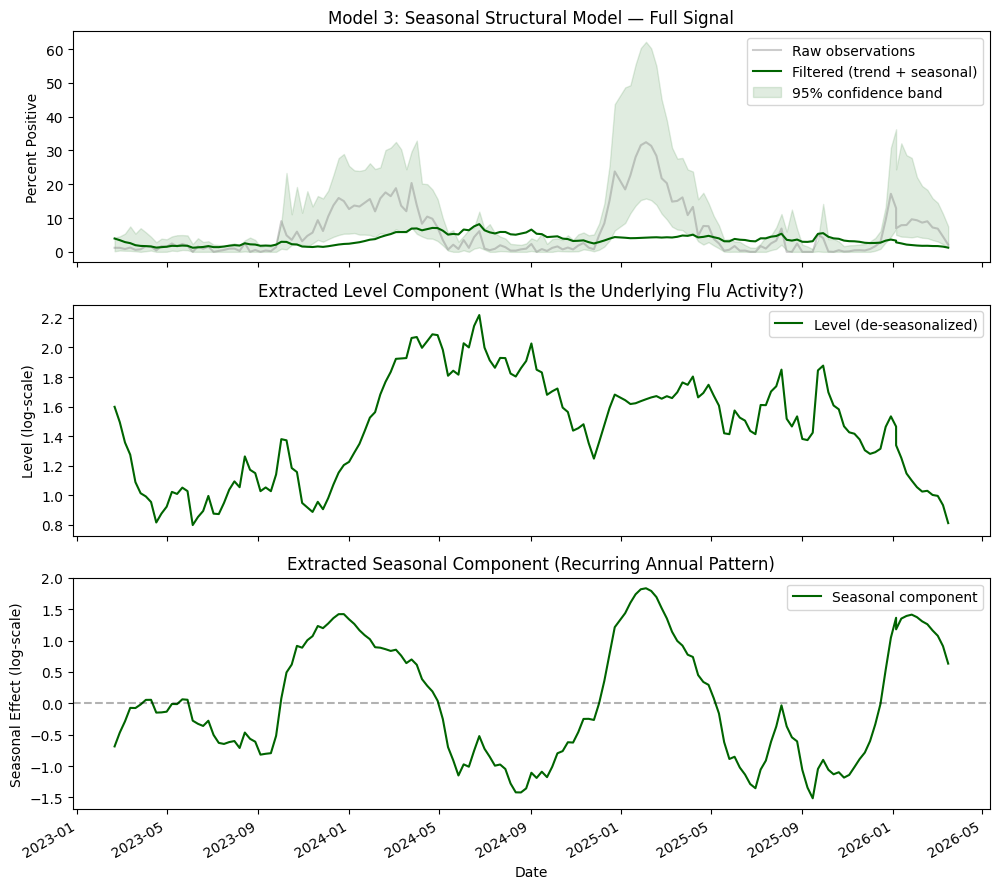

In [83]:
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

skip = 0
test_dates = test['DATE'].values[skip:]

# Panel 1: Full filtered signal (original scale)
axs[0].plot(test_dates, test_raw[skip:], alpha=0.4, label='Raw observations', color='gray')
axs[0].plot(test_dates, seasonal_states[skip:], label='Filtered (trend + seasonal)', color='darkgreen')
axs[0].fill_between(test_dates, seasonal_lower[skip:], seasonal_upper[skip:],
                alpha=0.12, color='darkgreen', label='95% confidence band')
axs[0].set_ylabel('Percent Positive')
axs[0].set_title('Model 3: Seasonal Structural Model — Full Signal')
axs[0].legend()

# Panel 2: De-seasonalized level (log-scale)
axs[1].plot(test_dates, seasonal_states_log[skip:], color='darkgreen', label='Level (de-seasonalized)')
axs[1].set_ylabel('Level (log-scale)')
axs[1].set_title('Extracted Level Component (What Is the Underlying Flu Activity?)')
axs[1].legend()

# Panel 3: Seasonal component (log-scale)
axs[2].plot(test_dates, seasonal_log[skip:], color='darkgreen', label='Seasonal component')
axs[2].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[2].set_xlabel('Date')
axs[2].set_ylabel('Seasonal Effect (log-scale)')
axs[2].set_title('Extracted Seasonal Component (Recurring Annual Pattern)')
axs[2].legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [84]:
ca_seasonal_params = test_raw, seasonal_lower, seasonal_upper
print(f'Empirical Coverage (Seasonal Model): {empirical_coverage(ca_seasonal_params)}')

ljb_seasonal = acorr_ljungbox(vk_seasonal, lags=52, return_df=True)
print(f'Percentage of p-values < 0.05 (Seasonal Model): {len(ljb_seasonal[ljb_seasonal['lb_pvalue'] < 0.05]) / len(ljb_seasonal)}')

Empirical Coverage (Seasonal Model): 0.9813664596273292
Percentage of p-values < 0.05 (Seasonal Model): 0.019230769230769232


The 98.1% coverage indicates slightly conservative prediction intervals. The Ljung-Box result of 1.9% is well below the 5% threshold, indicating that the standardized innovations show no significant residual autocorrelation and the model is capturing effectively temporal dynamics.

The adaptive R produced substantial improvement over the fixed-R version, which achieved 11.5% on the Ljung-Box diagnostic. The time-varying observation noise allows the filter to widen its uncertainty during outbreak surges and tighten during stable periods, resulting in better-calibrated prediction intervals.

### **Compare Models**

In [85]:
# Precompute for test set
fourier_test = build_fourier_features(test['WEEK'].values)
covid_mask_test = test['DATE'].values >= pd.Timestamp('2020-03-11')

# Compute NLL on test set for each model
nll_test_baseline = neg_log_likelihood_baseline(
    np.log([Q_mle_baseline, R_mle_baseline]), test_log, A_est)
nll_test_llt = neg_log_likelihood_llt(
    np.log([q_level_mle, q_trend_mle, r_mle_llt]), test_log)

alpha_logit = np.log(alpha_s / (1.0 - alpha_s))
nll_test_seasonal = neg_log_likelihood_seasonal(
    np.array([np.log(q_level_s), np.log(q_trend_s), np.log(q_seasonal_pre_s), 
              np.log(q_seasonal_post_s), np.log(r_s), alpha_logit]),
    test_log_seasonal, fourier_test, covid_mask_test)

seasonal_combined = np.expm1(seasonal_states_log + seasonal_log)

models = {'Baseline (Random Walk)': {'filtered': baseline_states,
                                     'n_params': 2,
                                     'nll': nll_test_baseline},
            'Local Linear Trend': {'filtered': llt_states,
                                   'n_params': 3,
                                   'nll': nll_test_llt},
            'Seasonal (Fourier)': {'filtered': seasonal_combined,
                                   'n_params': 6,
                                   'nll': nll_test_seasonal}}

comparison_rows = []
skip = 40
for name, m in models.items():
    rmse = np.sqrt(mean_squared_error(test_raw[skip:], m['filtered'][skip:]))
    mae = mean_absolute_error(test_raw[skip:], m['filtered'][skip:])
    aic = 2 * m['n_params'] + 2 * m['nll']
    comparison_rows.append({'Model': name,
                            'RMSE': round(rmse, 4),
                            'MAE': round(mae, 4),
                            'Test NLL': round(m['nll'], 2),
                            'AIC': round(aic, 2)})

pd.DataFrame(comparison_rows)

,Model,RMSE,MAE,Test NLL,AIC
0,Baseline (Random Walk),1.4706,0.9180,-16.34,-28.67
1,Local Linear Trend,1.2975,0.8236,-12.47,-18.95
2,Seasonal (Fourier),1.9237,1.3076,-4.73,2.54


The baseline and LLT achieve lower RMSE/MAE because they track observations more closely. The random walk in particular chases each data point, yielding low point-error metrics at the cost of poorly calibrated uncertainty. The seasonal model's higher RMSE reflects that, by decomposing the signal into level, trend, and seasonal components, the seasonal model produces a smoother filtered estimate that sacrifices point accuracy for interpretability and better-calibrated prediction intervals. When we examine the diagnostics that matter for model adequacy, the seasonal model is the best-specified of the three. Low RMSE alone does not indicate a good filter; a model that simply copies each observation would achieve zero RMSE but provide no insight or useful forecasts.

### **Forecasting**

Forecasts and their associated error variance matrices can be obtained routinely in state space time series analysis based on linear Gaussian models by continuing the Kalman filter beyond $t = n$ with $Z_t= 0$ for $t > n$. Of course, for the computation of $\bar{y}_{n+j}$ and $\bar{F}_{n+1}$ $t > n$, we take $Z_{n+j}$ as their actual values for $j = 1, ..., J$. Similar results hold for forecasting values of the state vector a and hence for forecasting linear functions of elements of at. The results remain valid for MVLUE forecasting in the non-normal case and for Bayesian analysis using Lemmas 2 to 4. These results for forecasting are a particularly elegant feature of state space methods for time series analysis.

For j = 1 the forecast is straightforward:

$$\bar{y}_{n+1} = Z_{n+1}a_{n+1}$$

where $a_{n+1}$ is the estimate (4.21) of $\alpha_{n+1}$ produced by the Kalman filter. 

The conditional mean square error matrix

$$\hat{F}_{n+1} = Z_{n+1}P_{n+1}Z^{'}_{n+1}+H_{n+1}$$

For j = 2, ..., J:

$$\bar{y}_{n+1} = Z_{n+1}\bar{a}_{n+1}$$

with conditional mean square error matrix:
$$\hat{F}_{n+1} = Z_{n+j}\bar{P}_{n+j}Z^{'}_{n+j}+H_{n+j}$$

For j = 1, ..., J-1 and with $\bar{a}_{n+j}=a_{n+1}$:

$$\bar{a}_{n+j+1}=T_{n+j}\bar{a}_{n+j}$$

Also, j = 1, ..., J-1:

$$\bar{P}_{n+j+1}=T_{n+j}\bar{P}_{n+j}T^{'}_{n+j}+R_{n+j}Q_{n+j}R^{'}_{n+j}$$

In [86]:
# Forecast beyond test data
n_forecast = 52

params_forecast_baseline = A_base, Q_base, H_base, xk_base, Pk_base
forecast_1_log, upper_1_log, lower_1_log = forecast(params_forecast_baseline, n_forecast)

params_forecast_llt = A_llt, Q_llt, H_llt, xk_llt, Pk_llt
forecast_2_log, upper_2_log, lower_2_log = forecast(params_forecast_llt, n_forecast)

# Build seasonal matrices with baseline R (no adaptive R for forecasting)
A_seasonal, Q_seasonal, R_seasonal = build_seasonal_matrices(
    q_level_s, q_trend_s, q_seasonal_post_s, r_s)

last_week = test['WEEK'].values[-1]
forecast_weeks = np.array([(last_week + i) % 52 + 1 for i in range(n_forecast)])
params_forecast_seasonal = A_seasonal, Q_seasonal, R_seasonal, xk_seasonal, Pk_seasonal
forecast_3_log, upper_3_log, lower_3_log = forecast_seasonal(
    params_forecast_seasonal, forecast_weeks, n_forecast)

In [87]:
# Forecast ranges
forecast_start = len(test_raw)
forecast_range = range(forecast_start, forecast_start + n_forecast)
test_range = range(len(test_raw))

In [88]:
# Generate forecast dates continuing weekly from end of test set
forecast_dates = pd.date_range(start=test['DATE'].values[-1], periods=n_forecast + 1, freq='W')[1:]

def forecast_plots(filtered, filtered_lower, filtered_upper, 
                   raw_values, upper, lower, title):
    fig, ax = plt.subplots()
    ax.plot(test['DATE'], test_raw, color='black', marker='.', 
            linestyle='none', alpha=0.5, label='Test observations')
    ax.plot(test['DATE'], filtered, color='darkgreen', label='Filtered')
    ax.fill_between(test['DATE'], filtered_lower, filtered_upper, 
                    alpha=0.12, color='darkgreen')
    ax.plot(forecast_dates, raw_values, color='darkgreen', linestyle='--', 
            label='Forecast')
    ax.fill_between(forecast_dates, lower, upper, alpha=0.12, color='darkgreen')
    ax.axvline(forecast_dates[0], color='black', linestyle='--', alpha=0.3)
    ax.set_xlabel('Date')
    ax.set_ylabel('Percent Positive')
    ax.set_title(title)
    ax.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

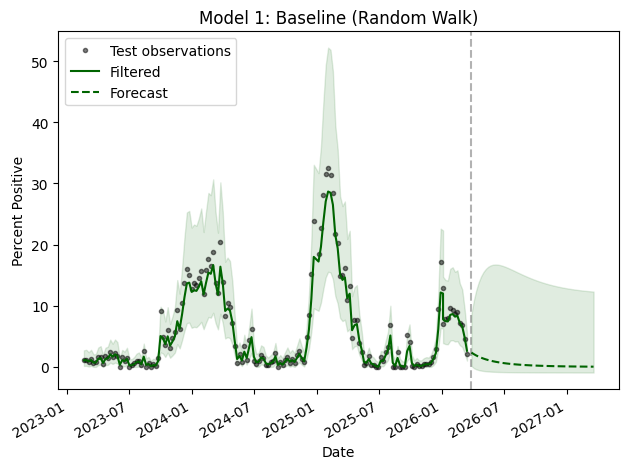

In [89]:
forecast_1_raw = np.expm1(forecast_1_log)
upper_1_raw = np.expm1(upper_1_log)
lower_1_raw = np.expm1(lower_1_log)


forecast_plots(baseline_states, baseline_lower, baseline_upper,
               forecast_1_raw, upper_1_raw, lower_1_raw, 'Model 1: Baseline (Random Walk)')

The baseline model produces a flat forecast that decays toward zero. With no structural components, it has nothing to project forward except the last filtered state, and the $A\approx 0.98$ coefficient causes it to slowly shrink. The confidence bands fan out symmetrically but remain relatively contained.

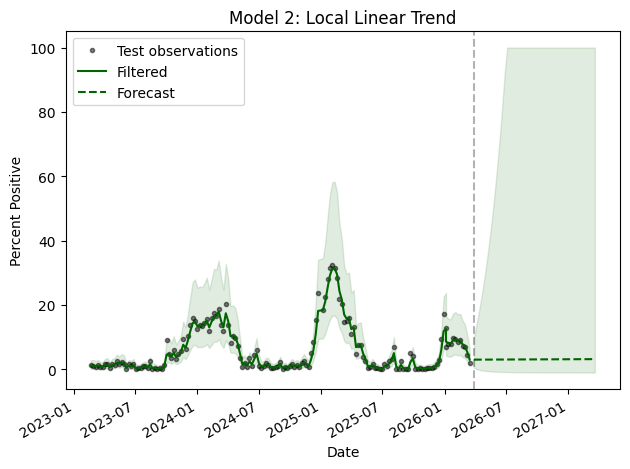

In [90]:
forecast_2_raw = np.expm1(forecast_2_log)
upper_2_raw = np.minimum(np.expm1(upper_2_log), 100)
lower_2_raw = np.expm1(lower_2_log)

forecast_plots(llt_states, llt_lower, llt_upper,
               forecast_2_raw, upper_2_raw, lower_2_raw, 'Model 2: Local Linear Trend')

The Local Linear Trend  also produces a nearly flat forecast, since the estimated trend is effectively zero. However, its confidence bands explode to 100% within a few months, reflecting the compounding uncertainty from the trend state. Without seasonality, it cannot make meaningful long-range predictions and the bands correctly reflect this.

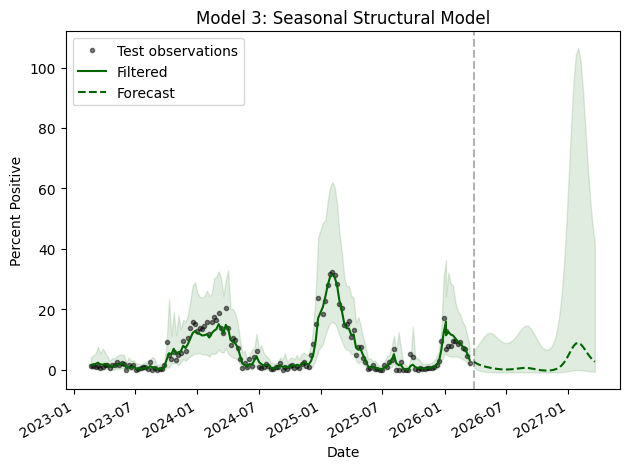

In [91]:
forecast_3_raw = np.expm1(forecast_3_log)
upper_3_raw = np.expm1(upper_3_log)
lower_3_raw = np.expm1(lower_3_log)

forecast_plots(seasonal_combined, seasonal_lower, seasonal_upper,
               forecast_3_raw, upper_3_raw, lower_3_raw, 'Model 3: Seasonal Structural Model')

The Seasonal Structural Model is the only model that produces a structurally informative forecast. The dashed forecast line shows the expected winter surge peaking around late 2026 / early 2027, driven by the Fourier seasonal component. This demonstrates the ability of the model to anticipate the timing and approximate magnitude of the next flu season based on learned seasonal patterns. The confidence bands widen over the forecast horizon as expected, but the seasonal shape remains visible within them.

### **Rauch–Tung–Striebel smoother**

### Rauch-Tung-Striebel Smoother (Backward Algorithm)

The Rauch–Tung–Striebel smoother uses the inputs, $x_k$, $P_k$, and $\bar{P}_k$ for each k = 1, ..., n, computed from the Kalman filter algorithm.

The smoother gain is:

$$C_k = P_k A^T (\bar{P}_k)^{-1}$$

where $\bar{P}_k = AP_{k-1}A^T + Q$ is the predicted covariance from the forward pass.

State Smoothing ("Backward Pass")

1. Initialize: $\hat{x}_n = {x}_n$ and $\hat{P}_n = P_n$

2. For $k = n - 1, n - 2, ..., 1$:

$$C_k = P_k A^T (\bar{P}_k)^{-1}$$

$$\hat{x}_k = {x}_k + C_k(\hat{x}_{k+1} - A{x}_k)$$

$$\hat{P}_k = P_k + C_k(\hat{P}_{k+1} - \bar{P}_k)C_k^T$$

In [92]:
def RTS_smoother(params, skip=0):
    xk_filtered, Pk_filtered, Pk_bar, A_list = params
    n = len(xk_filtered)

    xk_smoothed = list(xk_filtered.copy())
    Pk_smoothed = list(Pk_filtered.copy())

    for k in range(n - 2, skip - 1, -1):
        A_k = A_list[k] if isinstance(A_list, list) else A_list
        Ck = Pk_filtered[k] @ np.linalg.solve(Pk_bar[k+1], A_k).T
        xk_smoothed[k] = xk_filtered[k] + Ck @ (xk_smoothed[k+1] - A_k @ xk_filtered[k])
        Pk_smoothed[k] = Pk_filtered[k] + Ck @ (Pk_smoothed[k+1] - Pk_bar[k+1]) @ Ck.T

    return xk_smoothed, Pk_smoothed

In [93]:
def plot_RTS_smoother(params, title):
    smoothed_log, smoothed_lower_log, smoothed_upper_log = params
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(train['DATE'], train_log, alpha=0.3, color='gray', label='Observations (log scale)')
    ax.plot(train['DATE'], smoothed_log, color='darkgreen', label='RTS smoother')
    ax.fill_between(train['DATE'], smoothed_lower_log, smoothed_upper_log,
                    alpha=0.12, color='darkgreen', label='Smoother 95% band')
    ax.set_xlabel('Date')
    ax.set_ylabel('Log Percent Positive')
    ax.set_title(title)
    ax.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

In [94]:
# Run filter on training data to get RTS inputs
_, _, _, _, _, xk_rts_base, Pk_rts_base, Pk_bars_base, _ = run_baseline_filter(
    [A_est, Q_mle_baseline, R_mle_baseline], train_log)

# Run smoother on training data
baseline_rts_params = xk_rts_base, Pk_rts_base, Pk_bars_base, A_base
xk_smoothed_base, Pk_smoothed_base = RTS_smoother(baseline_rts_params)

# Extract scalar values
smoothed_log_base = np.array([x.item() for x in xk_smoothed_base])
smoothed_sigma_base = np.array([np.sqrt(P.item()) for P in Pk_smoothed_base])
smoothed_upper_log_base = smoothed_log_base + 2 * smoothed_sigma_base
smoothed_lower_log_base = smoothed_log_base - 2 * smoothed_sigma_base

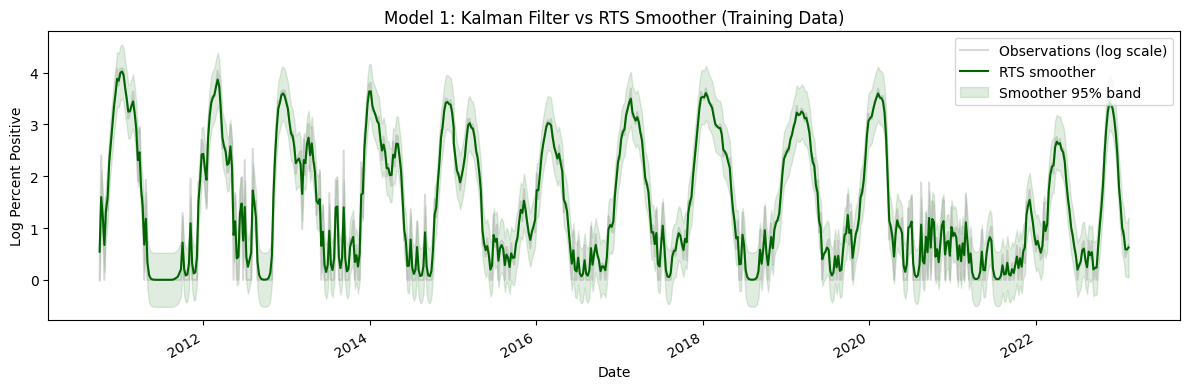

In [95]:
plot_RTS_smoother_base_params = smoothed_log_base, smoothed_lower_log_base, smoothed_upper_log_base
title = 'Model 1: Kalman Filter vs RTS Smoother (Training Data)'
plot_RTS_smoother(plot_RTS_smoother_base_params, title)

In [96]:
# Run filter on training data to get RTS inputs
_, _, _, _, _, _, xk_rts_llt, Pk_rts_llt, Pk_bars_llt, _ = run_llt_filter(
    [q_level_mle, q_trend_mle, r_mle_llt], train_log)

# Run smoother on training data
llt_rts_params = xk_rts_llt, Pk_rts_llt, Pk_bars_llt, A_llt
xk_smoothed_llt, Pk_smoothed_llt = RTS_smoother(llt_rts_params)

# Extract level (index 0) from state vector and covariance matrix
smoothed_log_llt = np.array([x[0, 0] for x in xk_smoothed_llt])
smoothed_sigma_llt = np.array([np.sqrt(P[0, 0]) for P in Pk_smoothed_llt])
smoothed_upper_log_llt = smoothed_log_llt + 2 * smoothed_sigma_llt
smoothed_lower_log_llt = smoothed_log_llt - 2 * smoothed_sigma_llt

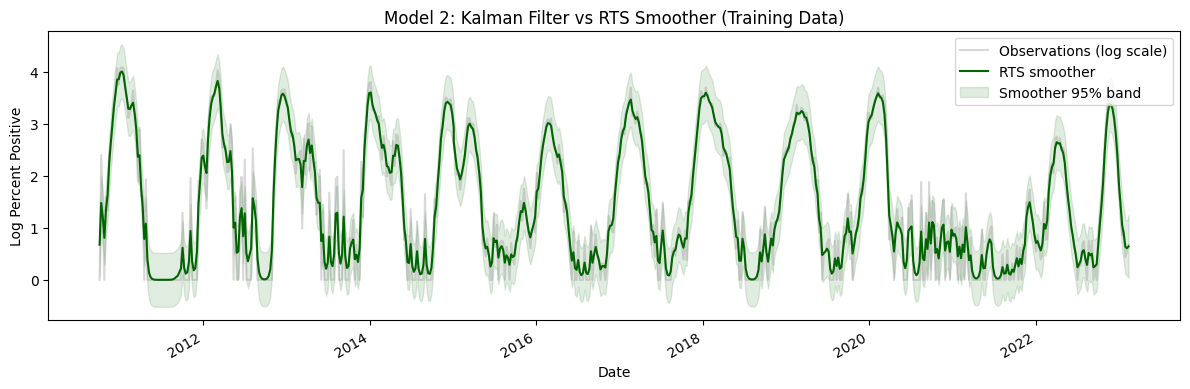

In [97]:
plot_RTS_smoother_base_params = smoothed_log_llt, smoothed_lower_log_llt, smoothed_upper_log_llt
title = 'Model 2: Kalman Filter vs RTS Smoother (Training Data)'
plot_RTS_smoother(plot_RTS_smoother_base_params, title)

Models 1 and 2 produce visually similar smoothed estimates, which is expected given that the LLT's trend component was estimated at effectively zero. Both models reduce to level-only smoothing. The bands are narrow and uniform across the series, confirming that both models treat the seasonal peaks as part of the signal rather than noise.

In [98]:
# Run filter on training data to get RTS inputs
(_, _, _, _, _, _, _, _,
 xk_rts_seasonal, Pk_rts_seasonal, Pk_bars_seasonal) = run_seasonal_filter(
    parameters_seasonal, train_log, train['WEEK'].values, train['DATE'].values)

# Run smoother
seasonal_rts_params = xk_rts_seasonal, Pk_rts_seasonal, Pk_bars_seasonal, A_seasonal
xk_smoothed_seasonal, Pk_smoothed_seasonal = RTS_smoother(seasonal_rts_params)

# Reconstruct full signal (level + seasonal)
fourier_train = build_fourier_features(train['WEEK'].values)

smoothed_level_log = np.array([x[0, 0] for x in xk_smoothed_seasonal])
smoothed_seasonal_component = np.array([
    sum(xk_smoothed_seasonal[k][2 + j, 0] * fourier_train[k, j] for j in range(6))
    for k in range(len(xk_smoothed_seasonal))
])
smoothed_combined_log = smoothed_level_log + smoothed_seasonal_component

smoothed_sigma_seasonal = np.array([np.sqrt(P[0, 0]) for P in Pk_smoothed_seasonal])
smoothed_upper_log_seasonal = smoothed_combined_log + 2 * smoothed_sigma_seasonal
smoothed_lower_log_seasonal = smoothed_combined_log - 2 * smoothed_sigma_seasonal

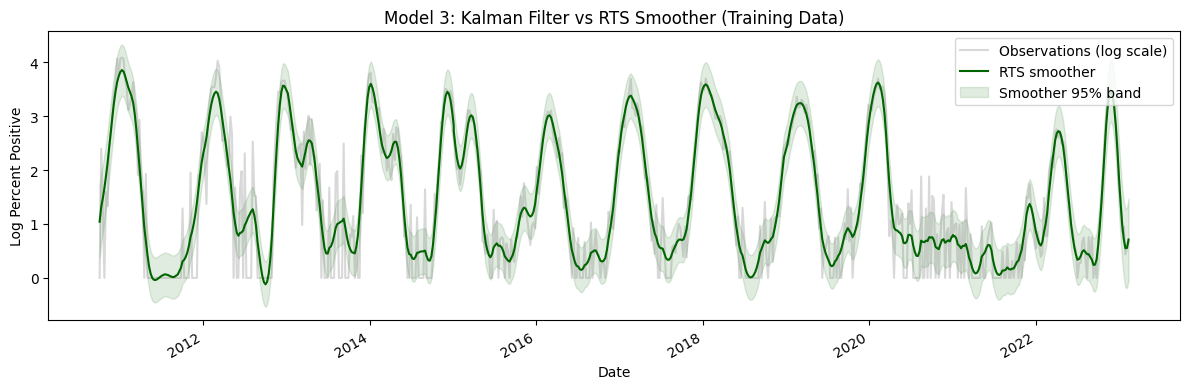

In [99]:
plot_RTS_smoother_base_params = smoothed_combined_log, smoothed_lower_log_seasonal, smoothed_upper_log_seasonal
title = 'Model 3: Kalman Filter vs RTS Smoother (Training Data)'
plot_RTS_smoother(plot_RTS_smoother_base_params, title)

Model 3's smoother stands out in two ways.
1. The smoothed line tracks the seasonal peaks more closely than Models 1 and 2, because the Fourier components allow it to attribute the recurring winter surges to a structured seasonal pattern rather than absorbing them entirely into the level. 
2. The bands are noticeably tighter, particularly during the stable off-season periods, because the seasonal decomposition explains more of the variance structurally, leaving less residual uncertainty. The COVID-era disruption around 2020–2021 is also visible as a period of wider bands and suppressed seasonal amplitude, consistent with the model's pre/post-COVID split on seasonal process noise.

### **References**

Byrd et. al. (1994). "A LIMITED MEMORY ALGORITHM FOR BOUND CONSTRAINED OPTIMIZATION". NORTHWESTERN UNIVERSITY Department of Electrical Engineering and Computer Science.

Durbin, J., & Koopman, S.J. (2012). Time Series Analysis by State Space Methods (2nd ed.). Oxford University Press.

J. J. More and D. J. Thuente (1990). "On line search algorithms with guaranteed sufficient decrease". Mathematics and Computer Science Division Preprint MCS-P153-0590.
Argonne National Laboratory (Argonne, IL).

Miller, J.W. (2016). "Kalman Filter and Smoother." Lecture Notes on Advanced Stochastic Modeling. Duke University, Durham, NC.

Rauch, H.E., Tung, F., & Striebel, C.T. (1965). "Maximum Likelihood Estimates of Linear Dynamic Systems." AIAA Journal, 3(8), 1445–1450.

Shumway, R.H., & Stoffer, D.S. (2017). Time Series Analysis and Its Applications: With R Examples (4th ed.). Springer.

Welch, G., & Bishop, G. (2006). "An Introduction to the Kalman Filter." Department of Computer Science, University of North Carolina at Chapel Hill.

Zhu et. al. (1994). "L-BFGS-B - FORTRAN SUBROUTINES FOR LARGESCALE BOUND CONSTRAINED OPTIMIZATION". NORTHWESTERN UNIVERSITY Department of Electrical Engineering and Computer Science.